# pow benchmark — compact summary

Short view: the per-N summary table plus a single solve-time plot. The full walkthrough (methodology, ECDF, density, normalized diagnostics, cross-implementation comparison) lives in `explore_results.ipynb`. Data loading, metrics, and plot helpers are shared via `_lib.py`.


In [1]:
from _lib import load_runs, plot_solve_times, show_table, summary_table

runs = load_runs()

loaded 2 file(s) from /Users/pikachu/dev/pow/results
  bench-oniguruma-20260525T120719Z-shani.json: oniguruma/shani threads=32 target=60s N=6..9 rows=81
  bench-oniguruma-20260525T132118Z-python.json: oniguruma/python threads=1 target=60s N=4..7 rows=78


## Summary table

Per `(label, N)`: number of runs, median and mean elapsed, nearest-rank p95, stddev, effective hashrate (`Σattempts / Σelapsed`). p95 and stddev are masked (`—`) when fewer than `MIN_RUNS_TAIL = 20` runs are available — at that few samples those columns are dominated by individual outliers, not the underlying distribution. Times are rounded to 3 decimals; hashrate is rendered as a plain integer with space-thousand separators.


In [2]:
show_table(summary_table(runs))

,label,n_zeros,runs,median_s,mean_s,p95_s,max_s,stddev_s,eff_hps
0,oniguruma/shani,6,30,0.034,0.046,0.119,0.175,0.041,397 072 739
1,oniguruma/shani,7,30,0.522,0.717,2.544,3.349,0.784,398 671 101
2,oniguruma/shani,8,20,6.455,10.031,34.735,35.892,11.189,403 035 882
3,oniguruma/shani,9,1,255.184,255.184,—,255.184,—,405 896 766
4,oniguruma/python,4,30,0.036,0.057,0.168,0.169,0.049,1 327 607
5,oniguruma/python,5,30,0.567,0.813,2.466,2.485,0.666,1 329 816
6,oniguruma/python,6,13,8.220,14.954,—,40.911,—,1 336 499
7,oniguruma/python,7,5,71.889,69.629,—,176.789,—,1 328 216


## Solve time vs N

Dots are individual runs (dodged horizontally by implementation, slightly jittered). The thick tick in each cluster is the median; whiskers show the raw p2.5-p97.5 spread of observations — *not* a confidence interval; the spread does not narrow with more runs. The grey dashed horizontal is the target budget; dotted verticals mark integer-N anchors.


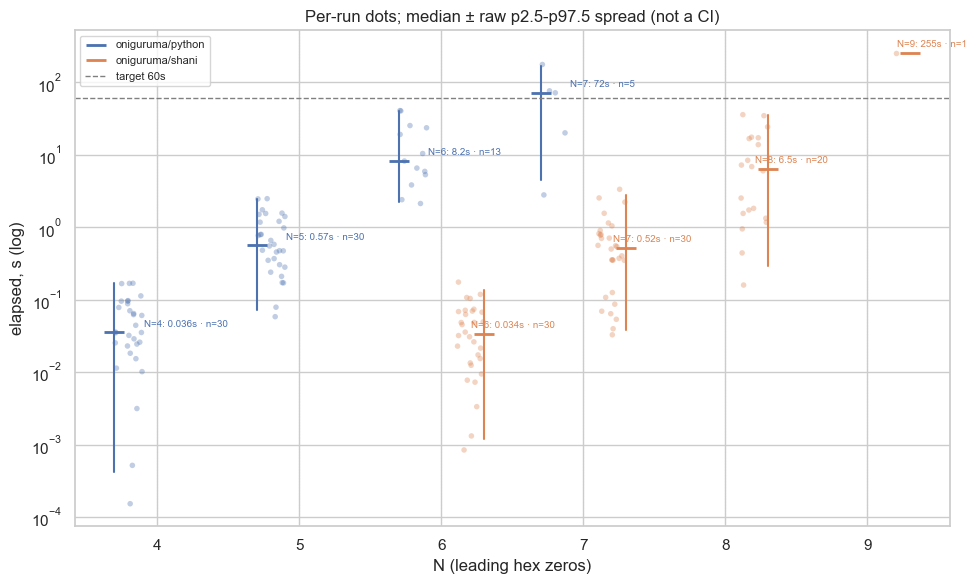

In [3]:
plot_solve_times(runs)